# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: https://www.mia.uni-saarland.de/weickert/Papers/book.pdf "Anisotropic Diffusion
in Image Processing" Not actually reading the entire book of course- only picking up the mathematical definitions of anisotropic diffusion and implementation details.
* Source 2: https://www.researchgate.net/publication/380999156_Visual_Alchemy_The_Science_of_Instagram_Filters "The Science of Instagram Filters" - mathematical definitions of vignetting, brightening, darkening. Very basic equations and no implementation details.
* Source 3: https://medium.com/@kdorichev/edges-detection-in-computer-vision-using-convolutions-5332efad3c91
Explains what is edge detection and why some basic edge detection matrices work. I ended up using a basic Sobel 3x3 kernel
* Source 4: https://www.sciencedirect.com/topics/computer-science/anisotropic-diffusion Similar to source 1- I used the Perona-Malik Diffusion equation outlined in thsi paper, as a specific example to try to implement.
* Source 5: https://medium.com/@akashsingh9303/image-processing-using-convolution-kernels-in-python-a-practical-guide-2da3252b033a Medium post describing a practical pipeline for image processing in python, with some example kernels (didn't end up being very useful since I already knew how to implement the code, so...)

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
!git clone https://github.com/gaoruosong/CS131_release.git

Cloning into 'CS131_release'...
remote: Enumerating objects: 2762, done.
remote: Counting objects: 100% (362/362), done.
remote: Compressing objects: 100% (257/257), done.
remote: Total 2762 (delta 271), reused 105 (delta 105), pack-reused 2400 (from 4)
Receiving objects: 100% (2762/2762), 187.61 MiB | 22.86 MiB/s, done.
Resolving deltas: 100% (822/822), done.


In [2]:
%pwd

'/content'

In [3]:
%cd CS131_release/spring_2026/project1_release/option_A

/content/CS131_release/spring_2026/project1_release/option_A


In [4]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from time import time
from skimage import io
import math

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

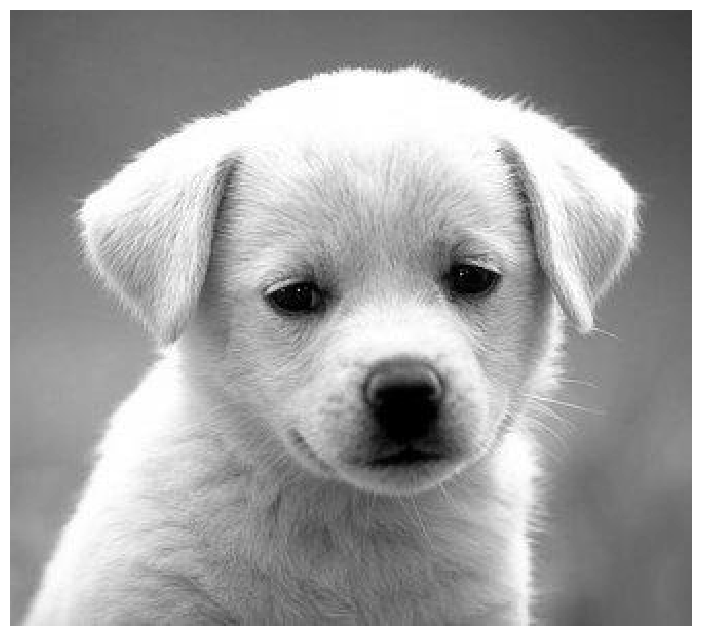

In [5]:
# Open image as grayscale
dog_img = io.imread('dog.jpg', as_gray=True)

# Show image
plt.imshow(dog_img)
plt.axis('off')
plt.show()

In [6]:
# Part (1): helper functions & basic filters

# In addition to copy-pasted zero_pad and conv_fast, this section includes helper functions to generate binomial filters,
# Brighten/darken images with local max/min, Sobel filters to detect edges, and a basic enhance contrast function using a 3x3 kernel.


# Various type issues: images can come either as integers or as floats. If it is an integer, then
# we have to clip to [0,255]. On the other hand, if a float, then it has to be clipped to [0,1].
# In other words, we should be using float in either case for computation, then clipping appropriately.
# The point being: the issue happens with clipping. Without manual clipping & conversion,
# Overflows can happen or python treats RGB int values like floats in the [0,1] range.

# After testing extensively with a ton of type conversions, type checking before return then manually clipping seems to be the only method:
#  if np.issubdtype(image.dtype, np.integer):
#     out = np.clip(out, 0, 255)
#  return out.astype(image.dtype)

def zero_pad(image, pad_height, pad_width, colored = False):
    """ Zero-pad an image.

    Ex: a 1x1 image [[1]] with pad_height = 1, pad_width = 2 becomes:

        [[0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0]]         of shape (3, 5)

    Args:
        image: numpy array of shape (H, W).
        pad_width: width of the zero padding (left and right padding).
        pad_height: height of the zero padding (bottom and top padding).

    Returns:
        out: numpy array of shape (H+2*pad_height, W+2*pad_width).
    """
    out = None

    if colored:
      H, W, C = image.shape  # colored
      out = np.zeros((H + 2*pad_height, W + 2*pad_width, C))
      for i in range(H):
        for j in range(W):
            out[i + pad_height, j + pad_width, :] = image[i, j, :]


    else:
      H, W = image.shape
      out = np.zeros((H + 2*pad_height, W + 2*pad_width))
      for i in range(H):
        for j in range(W):
            out[i + pad_height][j + pad_width] = image[i][j]


    if np.issubdtype(image.dtype, np.integer):
      out = np.clip(out, 0, 255)
    return out.astype(image.dtype)



def conv_fast(image, kernel, colored = False):
    """ An efficient implementation of convolution filter.

    This function uses element-wise multiplication and np.sum()
    to efficiently compute weighted sum of neighborhood at each
    pixel.

    Hints:
        - Use the zero_pad function you implemented above
        - There should be two nested for-loops
        - You may find np.flip() and np.sum() useful

    Args:
        image: numpy array of shape (Hi, Wi).
        kernel: numpy array of shape (Hk, Wk). Dimensions will be odd.

    Returns:
        out: numpy array of shape (Hi, Wi).
    """
    if colored:
      Hi, Wi, _ = image.shape
      out = np.zeros((Hi, Wi, 3))
    else:
      Hi, Wi = image.shape
      out = np.zeros((Hi, Wi))

    Hk, Wk = kernel.shape
    mid_height = Hk//2
    mid_width = Wk//2

    padded_image = zero_pad(image, mid_height, mid_width, colored)
    flipped_kernel = np.flip(kernel)

    if colored:
      for i in range(mid_height, Hi+mid_height):
        for j in range(mid_width, Wi+mid_width):
          for k in range(3):
            patch = padded_image[i-Hk+mid_height+1:i+mid_height+1, j-Wk+mid_width+1:j+mid_width+1, k].squeeze() ## important! slicing must be done in one step.
            out[i-mid_height, j-mid_width, k] = np.sum(patch * flipped_kernel)
    else:
      for i in range(mid_height, Hi+mid_height):
        for j in range(mid_width, Wi+mid_width):
            patch = padded_image[i-Hk+mid_height+1:i+mid_height+1, j-Wk+mid_width+1:j+mid_width+1] ## important! slicing must be done in one step.
            out[i-mid_height][j-mid_width] = np.sum(patch * flipped_kernel)

    print(image.dtype, image.min(), image.max())
    print(out.dtype, out.min(), out.max())
    if np.issubdtype(image.dtype, np.integer):
      out = np.clip(out, 0, 255)
    return out.astype(image.dtype)


## for small sizes, binomial filters should work just as fine as Gaussian kernel
def binomial_filter(size = 3):
  ## builds a binomial filter of dimensions size x size
  out = np.zeros((size,size))
  for i in range(size):
    for j in range(size):  ## double for loop not the most efficient, but for all practical inputs, this is completely fine
      out[i][j] = math.comb(size-1, i) * math.comb(size-1, j)
  return out/(2**(2*size-2)) ## normalize.
  ## 1, 2, 1;
  ## wait. (3,0) that is 1,3,3,1. This doesn't actually work, that's why! The matrix is wrong!
  ## Modify to math.comb(size-1, i) should fix everything.


def efficient_binomial(size = 3):
  ## builds a binomial filter of dimensions size x size, using more numpy functionalities
  column = np.zeros((size, 1))
  row = np.zeros((1, size))
  for i in range(size):
    column[i][0] = math.comb(size-1, i)
    row[0][i] = math.comb(size-1, i)
  return np.matmul(column, row)/(2**(2*size-2))


def brighten_image(image, size = 3):
  ## takes in an image and replaces each pixel with the maximal value in a centered size x size patch
  ## assumption: size << image dimensions, otherwise this function is very inefficient
  ## brighten and darken only work for B&W, because it'd be more fun later to enhance RGB scales separately.
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      patch = padded_image[i-half:i+size-half, j-half:j+size-half]     ## also slightly inefficient, can probably skip padding
      out[i-half][j-half] = np.max(patch)

  return out


def darken_image(image, size = 3):
  ## takes in an image and replaces each pixel with the minimal value in a centered size x size patch
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      patch = padded_image[i-half:i+size-half, j-half:j+size-half]
      out[i-half][j-half] = np.min(patch)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)



def standard_sobel_filters(size = 3):
  ## builds Sobel filters. Returns a horizontal one and a vertical one.
  out_horizontal = np.zeros((size, 3))
  out_vertical = np.zeros((3, size))
  for i in range(size):
    out_horizontal[i][0] = -math.comb(size-1, i)
    out_horizontal[i][2] = math.comb(size-1, i)
    out_vertical[0][i] = -math.comb(size-1, i)
    out_vertical[2][i] = math.comb(size-1, i)

  return out_horizontal, out_vertical


def detect_edge(image, size = 3):
  ## uses sobel filters to detect edges
  ## we're going to keep this only B&W for now
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  horizontal, vertical = standard_sobel_filters(size)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      horizontal_patch = padded_image[i-half:i+size-half, j-1:j+2]
      vertical_patch = padded_image[i-1:i+2, j-half:j+size-half]
      Gx = np.sum(horizontal_patch * horizontal)
      Gy = np.sum(vertical_patch * vertical)
      out[i-half][j-half] = np.sqrt(Gx**2 + Gy**2)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)


def enhance_image(image, colored = False):
  ## this one only accommodates enhancing in 3x3 area.
  ## I may have forgotten about the copy-pasted conv_fast while writing this...
  out = np.zeros(image.shape)
  kernel = [[0,-1,0],[-1,5,-1],[0,-1,0]]
  padded_image = zero_pad(image, 1, 1, colored)

  if colored:
    for i in range(1, image.shape[0]+1):
      for j in range(1, image.shape[1]+1):
        for k in range(3):
          patch = padded_image[i-1:i+2, j-1:j+2, k]
          out[i-1][j-1][k] = np.sum(patch * kernel)
  else:
    for i in range(1, image.shape[0]+1):
      for j in range(1, image.shape[1]+1):
        patch = padded_image[i-1:i+2, j-1:j+2]
        out[i-1][j-1] = np.sum(patch * kernel)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

(np.float64(-0.5), np.float64(331.5), np.float64(299.5), np.float64(-0.5))

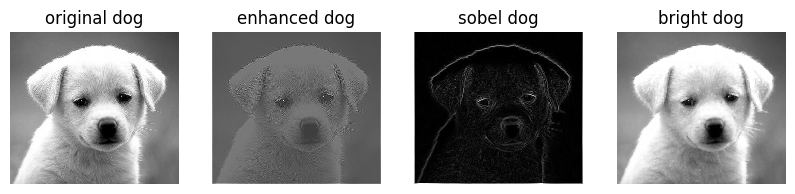

In [35]:
## testing basic helpers

enhanced_dog = enhance_image(dog_img)
sobel_dog = detect_edge(dog_img)
brighten_dog = brighten_image(dog_img)

plt.subplot(1,4,1)
plt.imshow(dog_img)
plt.title('original dog')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(enhanced_dog)
plt.title('enhanced dog')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(sobel_dog)
plt.title('sobel dog')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(brighten_dog)
plt.title('bright dog')
plt.axis('off')

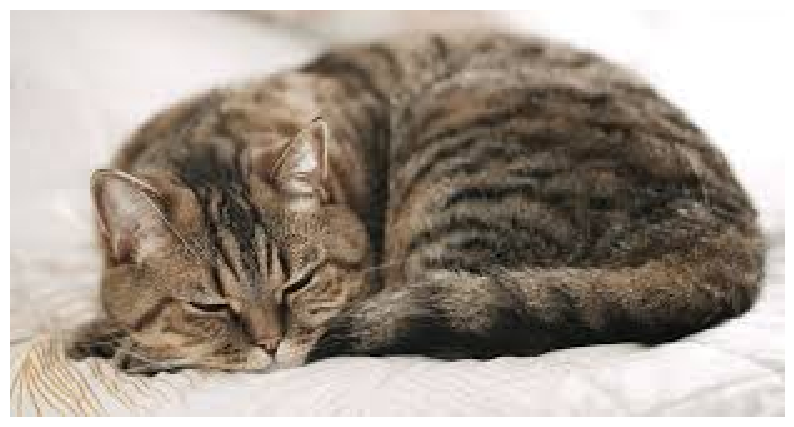

In [7]:
colored_cat = io.imread('sleeping-cat.jpeg', as_gray=False)

# Show image
plt.imshow(colored_cat)
plt.axis('off')
plt.show()

uint8 0 255
float64 12.73046875 255.0
uint8 0 255
float64 12.73046875 255.0


(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

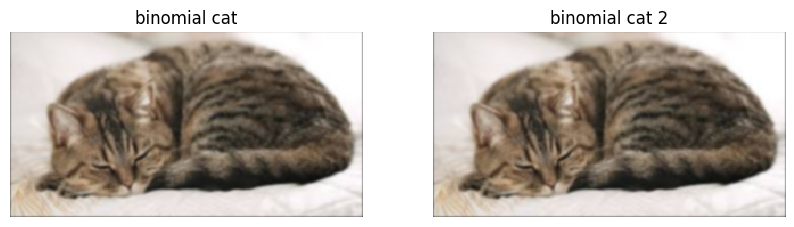

In [36]:
binomial_cat = conv_fast(colored_cat, binomial_filter(5), colored = True)
plt.subplot(1,2,1)
plt.imshow(binomial_cat)
plt.title('binomial cat')
plt.axis('off')

binomial_cat_2 = conv_fast(colored_cat, binomial_filter(5), colored = True)
plt.subplot(1,2,2)
plt.imshow(binomial_cat_2)
plt.title('binomial cat 2')
plt.axis('off')

(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

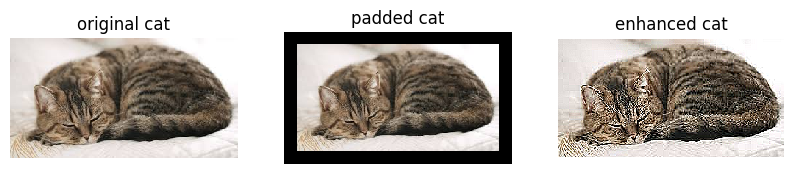

In [37]:
enhanced_colored_cat = enhance_image(colored_cat, colored = True)
padded_cat = zero_pad(colored_cat, 20, 20, colored = True)

plt.subplot(1,3,1)
plt.imshow(colored_cat)
plt.title('original cat')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(padded_cat)
plt.title('padded cat')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(enhanced_colored_cat)
plt.title('enhanced cat')
plt.axis('off')

## note that the enhanced cat looks horrible

In [25]:
## Part (2): RGB adjustments
## Here are functions that modify an image's R,G,B values separately using linear or sigmoid transformations.
## I also put a vignette function here- from a chosen center, the vignette function dims the image the further it is from the center,
## by default, the furthest points from the center will only be half as bright.

## a naive multiplication-based scale factor might just blur everything out.
## Idea 1: multiply (max - value)* scale)factor - this works fine for compression (factor < 1) but may break for expansion (factor > 1).
## It also does not work at all for negative factors.
## Idea 2: keep mean the same but re-scale. This doesn't
## a more sophisticated method? (Assume max = 1, min = 0) with value c, c & 1-c...
## c \rightarrow c', 1-c \rightarrow 1-c'; at scale factor = 1, the balance is 1/2, 1/2;
## with factor = a, how about we weight... a/1+a , 1/1+a?
## what are we weighing here?

def invert_color_tone(image):
  if np.issubdtype(image.dtype, np.integer):
    out = 255 - image
  else:
    out = 1 - image
  return out.astype(image.dtype)

def red_filter(image):
  out = np.zeros(image.shape)
  out[:, :, 0] = image[:, :, 0]
  return out.astype(image.dtype)

def green_filter(image):
  out = np.zeros(image.shape)
  out[:, :, 1] = image[:, :, 1]
  return out.astype(image.dtype)

def blue_filter(image):
  out = np.zeros(image.shape)
  out[:, :, 2] = image[:, :, 2]
  return out.astype(image.dtype)

def linear_rescale(image, scale_factor, shift_factor):
  red = image[:, :, 0]
  green = image[:, :, 1]
  blue = image[:, :, 2]

  rscale, gscale, bscale = scale_factor
  rshift, gshift, bshift = shift_factor
  out = np.zeros(image.shape)
  out[:, :, 0] = rscale * red + rshift
  out[:, :, 1] = gscale * green + gshift
  out[:, :, 2] = bscale * blue + bshift

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

def renormalize(image, scale_factor):
  red = image[:, :, 0]
  green = image[:, :, 1]
  blue = image[:, :, 2]
  rscale, gscale, bscale = scale_factor
  rmean = np.mean(red)
  gmean = np.mean(green)
  bmean = np.mean(blue)
  out = np.zeros(image.shape)
  out[:, :, 0] = rscale * (red - rmean)
  out[:, :, 1] = gscale * (green - gmean)
  out[:, :, 2] = bscale * (blue - bmean)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

def sigmoid_rescale(image, scale_factor = (0,0,0)):
  ## we begin with the sigmoid \sigma(a(c-0.5)), where a is the scale factor, c pixel value; then we try lagrange interpolate.
  ## we wish that when a=0, nothing is done, i.e. the pixel is still c. And when a is very large, it should approach maximal. when a very small (-\infty), minimal.
  ## Computed by hand, the correct polynomial, with x:=\sigma(a(c-0.5)), should be 2x^2-x-4cx(x-1). The problem with this function, though, is that it can go beyond 1
  ## (our placeholder maximum value).
  ## Thus we are forced to use a different method- after experimenting, we do f_a(c)=\sigma(-logit(c)+a), c pixel, a scale.
  ## this is increasing with a; and it ensures that for all values of c, f_0(c)=c, f_(-\infty)(c)=0, f_(\infty)(c)=1

  Hi, Wi, _ = image.shape
  out = np.zeros(image.shape)
  if np.issubdtype(image.dtype, np.integer):
    red = image[:, :, 0].astype(float)/255
    green = image[:, :, 1].astype(float)/255
    blue = image[:, :, 2].astype(float)/255
  else:
    red = image[:, :, 0].squeeze()
    green = image[:, :, 1].squeeze()
    blue = image[:, :, 2].squeeze()

  red = np.clip(red, 1e-8, 1-1e-8)
  green = np.clip(green, 1e-8, 1-1e-8)
  blue = np.clip(blue, 1e-8, 1-1e-8) ## down the line, we will be computing some logarithms that we would like to keep from internally blowing up.

  rscale, gscale, bscale = scale_factor
  for i in range(Hi):
    for j in range(Wi):
      r = 1/(1+np.exp(np.log((1-red[i][j])/red[i][j])-rscale))
      g = 1/(1+np.exp(np.log((1-green[i][j])/green[i][j])-gscale))
      b = 1/(1+np.exp(np.log((1-blue[i][j])/blue[i][j])-bscale))
      out[i, j, :] = [r,g,b]

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out*255, 0, 255)
  return out.astype(image.dtype)

def vignette(image, center = None, scale_factor = None):
  ##  Vignette (v) = a (Distance from Center)^(b). Set a=1/5.
  ##  pixel value *= (1 - v)
  ##  a is the scale factor. If it is not passed in, default to ensuring that the furthest point is half as bright.
  ##  This translates to 1-0.2d_max^b = 0.5, b = log_{d_max} (2.5) = (np.log(2.5)/np.log(d_max))
  Hi, Wi, _ = image.shape
  if center == None:
    center = (Hi//2, Wi//2)
  x, y = center

  if scale_factor == None:
    dmax = np.sqrt(max(x**2, (Hi-x)**2) + max(y**2, (Wi-y)**2))
    scale_factor = (np.log(2.5)/np.log(dmax))

  out = np.zeros(image.shape)
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      distance = np.sqrt((i-x)**2 + (j-y)**2)
      vignette = 1 - 0.2*np.power(distance, scale_factor)
      out[i][j] = image[i][j] * vignette

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

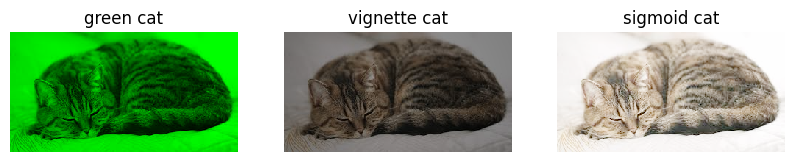

In [26]:
green_cat = linear_rescale(colored_cat, (0,1,0), (0,0,0))
vignette_cat = vignette(colored_cat)
sigmoid_cat = sigmoid_rescale(colored_cat, (1.25, 1.25, 1.25)) ## clipping does indeed solve internal division by zero. Good!


plt.subplot(1,3,1)
plt.imshow(green_cat)
plt.title('green cat')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(vignette_cat)
plt.title('vignette cat')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sigmoid_cat)
plt.title('sigmoid cat')
plt.axis('off')

(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

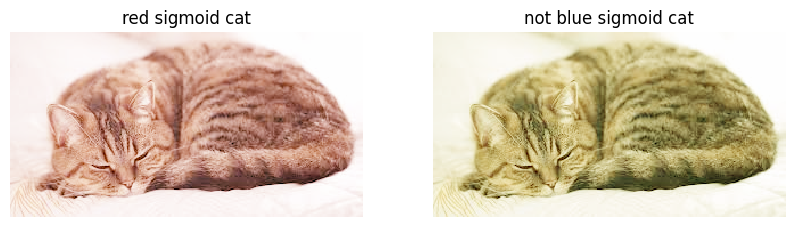

In [28]:
## more examples of filter effects
red_sigmoid_cat = sigmoid_rescale(colored_cat, (1.75, 1, 1))

plt.subplot(1,2,1)
plt.imshow(red_sigmoid_cat)
plt.title('red sigmoid cat')
plt.axis('off')

not_blue_sigmoid_cat = sigmoid_rescale(colored_cat, (1.25, 1.25, 0.5))

plt.subplot(1,2,2)
plt.imshow(not_blue_sigmoid_cat)
plt.title('not blue sigmoid cat')
plt.axis('off')

(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

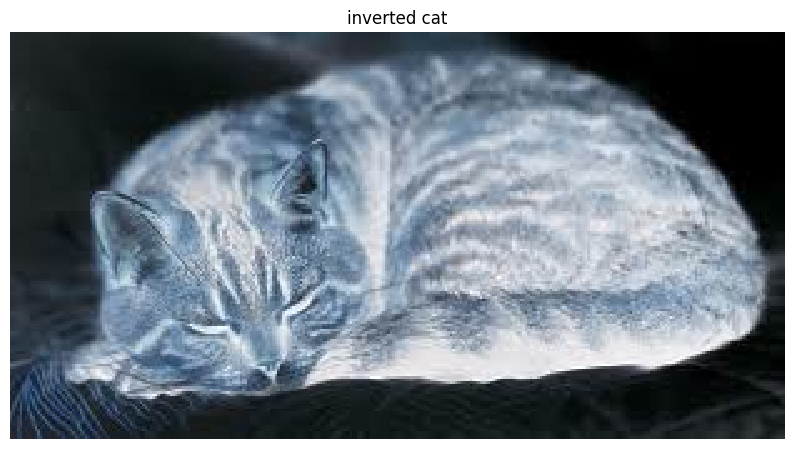

In [29]:
inverted_cat = invert_color_tone(colored_cat)

plt.subplot(1,1,1)
plt.imshow(inverted_cat)
plt.title('inverted cat')
plt.axis('off')

## this one is extremely cursed, lmao


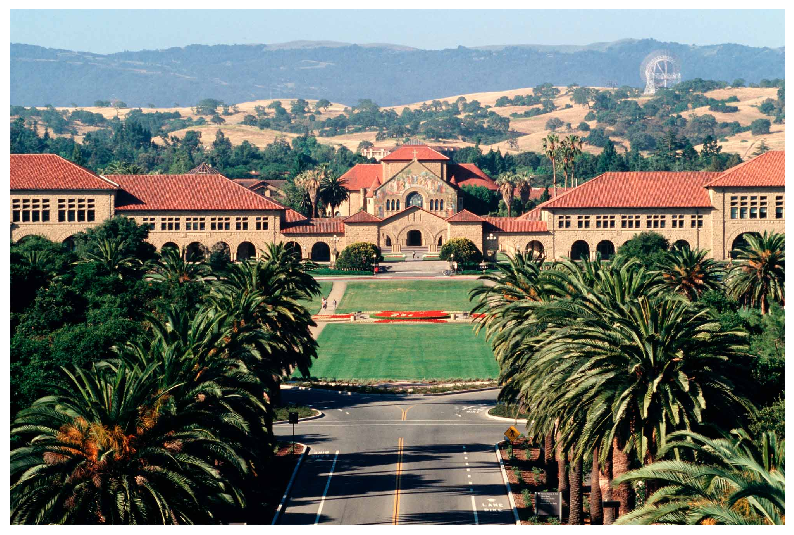

In [30]:
## high pixel photo for upcoming parts!
stanford = io.imread('Main-Quad-from-Palm-Dive-by-Linda-Cicero.jpg', as_gray=False)

# Show image
plt.imshow(stanford)
plt.axis('off')
plt.show()

In [44]:
## Part (3): local filters

## Binomial/Gaussian filters are able to introduce some blur; other basic filters can increase contrast.
## However, they do not take into account local features/contrast.
## Here, we implement local filters in two ways.
## First method, adapting the radius of the blur as we go, i.e. use different size Gaussian/binomials at each point.
## Second method, using Anisotropic diffusion. By solving a local equation,
## we are able to smooth more or less depending on local variance.


def pro_contrast_blur(image, colored = False):
  ## three settings: size = 1, size = 3, size = 5
  ## when local contrast is high, preserve individual pixels. When local contrast is low, blur in a larger region.
    if colored:
      Hi, Wi, _ = image.shape
      out = np.zeros((Hi, Wi, 3))
    else:
      Hi, Wi = image.shape
      out = np.zeros((Hi, Wi))

    std = np.std(image)

    padded_image = zero_pad(image, 2, 2, colored)
    small = np.array([[1]])
    medium = efficient_binomial(3)
    large = efficient_binomial(5)

    if colored:
      large = np.repeat(large[:,:,None], 3, axis = 2)
      medium = np.repeat(medium[:,:,None], 3, axis = 2)
      for i in range(2, Hi+2):
        for j in range(2, Wi+2):
          patch = padded_image[i-1:i+2, j-1:j+2, :]
          if np.std(patch) > 1.6 * std:
            out[i-2, j-2, :] = padded_image[i, j, :]
          elif np.std(patch) < 0.6 * std:
            out[i-2, j-2, :] = np.sum(padded_image[i-2:i+3, j-2:j+3, :] * large, axis = (0,1))
          else:
            out[i-2, j-2, :] = np.sum(patch * medium, axis = (0,1))

    else:
      for i in range(2, Hi+2):
        for j in range(2, Wi+2):
            patch = padded_image[i-1:i+2, j-1:j+2]
            if np.std(patch) > 1.6 * std:
              out[i-2, j-2] = padded_image[i, j]
            elif np.std(patch) < 0.6 * std:
              out[i-2, j-2] = np.sum(padded_image[i-2:i+3, j-2:j+3] * large)
            else:
              out[i-2, j-2] = np.sum(patch * medium)

    if np.issubdtype(image.dtype, np.integer):
      out = np.clip(out, 0, 255)
    return out.astype(image.dtype)

def anti_contrast_blur(image, colored = False):
  ## three settings: size = 1, size = 3, size = 5
  ## when local contrast is low, preserve individual pixels. When local contrast is high, blur in a larger region.
    if colored:
      Hi, Wi, _ = image.shape
      out = np.zeros((Hi, Wi, 3))
    else:
      Hi, Wi = image.shape
      out = np.zeros((Hi, Wi))

    std = np.std(image)

    padded_image = zero_pad(image, 2, 2, colored)
    small = np.array([[1]])
    medium = efficient_binomial(3)
    large = efficient_binomial(5)

    if colored:
      large = np.repeat(large[:,:,None], 3, axis = 2)
      medium = np.repeat(medium[:,:,None], 3, axis = 2)
      for i in range(2, Hi+2):
        for j in range(2, Wi+2):
          patch = padded_image[i-1:i+2, j-1:j+2, :]
          if np.std(patch) < 0.6 * std:
            out[i-2, j-2, :] = padded_image[i, j, :]
          elif np.std(patch) > 1.6 * std:
            out[i-2, j-2, :] = np.sum(padded_image[i-2:i+3, j-2:j+3, :] * large, axis = (0,1))
          else:
            out[i-2, j-2, :] = np.sum(patch * medium, axis = (0,1))

    else:
      for i in range(2, Hi+2):
        for j in range(2, Wi+2):
            patch = padded_image[i-1:i+2, j-1:j+2]
            if np.std(patch) < 0.6 * std:
              out[i-2, j-2] = padded_image[i, j]
            elif np.std(patch) > 1.6 * std:
              out[i-2, j-2] = np.sum(padded_image[i-2:i+3, j-2:j+3] * large)
            else:
              out[i-2, j-2] = np.sum(patch * medium)

    if np.issubdtype(image.dtype, np.integer):
      out = np.clip(out, 0, 255)
    return out.astype(image.dtype)



def image_gradient(image, colored = False):
  ## computes the gradient of an image, pixel by pixel.
  ## output is (image dimensions, 2) because we need an x-direction and y-direction.
  if colored:
    Hi, Wi, _ = image.shape
    out = np.zeros((Hi, Wi, 3))
  else:
    Hi, Wi = image.shape
    out = np.zeros((Hi, Wi))

  padded_image = zero_pad(image, 1, 1, colored)
  ## here, we want to convolve: horizontally, we do it with [-1, 0, 1].
  ## the point is we take a "derivative" at a point horizontally, averaging out the differences [i, j+1]-[i,j] and [i,j]-[i,j-1].
  ## vertically, [[1],[0],[-1]].
  horizontal_gradient = conv_fast(image, np.array([[-1, 0, 1]]), colored)
  vertical_gradient = conv_fast(image, np.array([[1],[0],[-1]]), colored)
  gradient = np.array([horizontal_gradient, vertical_gradient])
  return gradient

def compute_update(scaled_gradient, colored = False):
  horizontal_gradient = scaled_gradient[0,:,:,:].squeeze()
  vertical_gradient = scaled_gradient[1,:,:,:].squeeze()
  update = conv_fast(horizontal_gradient, np.array([[-5, 0, 5]]), colored) + conv_fast(vertical_gradient, np.array([[5],[0],[-5]]), colored)
  ## scaled up by a lot because I'm afriad integer rounding in conv_fast will cause issues
  return update


def perona_malik_step(image, scale_factor = 3, colored = False):
  if colored:
    Hi, Wi, _ = image.shape
    out = np.zeros((Hi, Wi, 3))
  else:
    Hi, Wi = image.shape
    out = np.zeros((Hi, Wi))

  out = image.copy()
  gradient = image_gradient(out, colored)
  scaled_gradient = np.zeros(gradient.shape)

  ## now we scale gradients by 1/(1+(gradient/scale)^2)
  if colored:
    for i in range(Hi):
      for j in range(Wi):
        for k in range(3):
          grad = np.sqrt(gradient[0,i,j,k]**2 + gradient[1,i,j,k]**2)
          scaled_gradient[:,i,j,k] = gradient[:,i,j,k] * 1/(1+(grad/scale_factor)**2)
  else:
    for i in range(Hi):
      for j in range(Wi):
        grad = np.sqrt(gradient[0,i,j]**2 + gradient[1,i,j]**2)
        scaled_gradient[:,i,j] = gradient[:,i,j] * 1/(1+(grad/scale_factor)**2)

  update = compute_update(scaled_gradient, colored)
  out = 0.2*update + image

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

def trivial_step(image, colored = False):
  if colored:
    Hi, Wi, _ = image.shape
    out = np.zeros((Hi, Wi, 3))
  else:
    Hi, Wi = image.shape
    out = np.zeros((Hi, Wi))

  out = image.copy()
  gradient = image_gradient(out, colored)
  update = compute_update(gradient, colored)
  out = 0.2*update + image

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)


def anisotropic_diffusion(image, trivial = False, colored = False):
  out = np.zeros(image.shape)
  image_copy = image.copy()
  if trivial:
    for i in range(2):
      image_copy = trivial_step(image_copy, colored)
    out = image_copy
  else:
    for i in range(2):
      image_copy = perona_malik_step(image_copy, colored)
    out = image_copy

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)




(np.float64(-0.5), np.float64(1999.5), np.float64(1330.5), np.float64(-0.5))

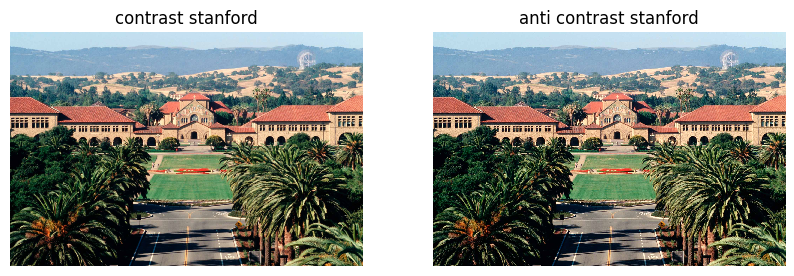

In [40]:
pro_contrast_stanford = pro_contrast_blur(stanford, colored = True)
anti_contrast_stanford = anti_contrast_blur(stanford, colored = True)

plt.subplot(1,2,1)
plt.imshow(pro_contrast_stanford)
plt.title('contrast stanford')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(anti_contrast_stanford)
plt.title('anti contrast stanford')
plt.axis('off')

## the problem here is mainly efficiency- code takes a long time to run.
## the difference between the two filters are subtle... but noticeable.
## funnily, anti-contrast creates more granularity, especially along edges.
## this is expected. But the result is that we actually perceive "more" contrast with anti-contrast.

In [45]:
trivial_anisotropic = anisotropic_diffusion(stanford, trivial = True, colored = True)
standard_anisotropic = anisotropic_diffusion(stanford, trivial = False, colored = True)

plt.subplot(1,2,1)
plt.imshow(trivial_anisotropic)
plt.title('trivial stanford')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(standard_anisotropic)
plt.title('standard stanford')
plt.axis('off')

## like the cell above, this one also takes a WHILE to run, lol
## anisotropic is buggy, however! the sign of the kernel needs to be flipped, and the scale factor is way off.

uint8 0 255
float64 -254.0 255.0
uint8 0 255
float64 0.0 0.0
uint8 0 255
float64 -1275.0 1070.0
uint8 0 0
float64 0.0 0.0
uint8 0 255
float64 -254.0 255.0
uint8 0 255
float64 0.0 0.0
uint8 0 255
float64 -1275.0 730.0
uint8 0 0
float64 0.0 0.0


ValueError: too many values to unpack (expected 2)

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.



This is a meandering exploration of various filters and image modifications. I started with implementing some very basic functionalities- brightening, darkening, blurring, edge detection. Departing from the previous notebook, I decided to see how to modify RGB images by modifying the R,G,B values separately. Here I decided to implement various rescalings- making the image more or less red, green, blue, et cetera- using both linear and sigmoid rescalings. Then finally I tried to play with locally-aware blurring, modifying the amount of blur based on how high the local variance is. I did a naive version which just adjusts the size of the binomial kernel based on standard deviation of the local patch, then I tried doing anisotropic diffusion (but since each iteration takes too long to run, I didn't get the chance to fix the code in time).